# Restaurant Rating Prediction using Machine Learning

## Project Overview

This project predicts restaurant ratings using machine learning based on restaurant characteristics such as location, cuisine, pricing, and customer engagement. Multiple regression models are trained and compared to identify the best-performing model.

## Objectives

- Understand the restaurant dataset.
- Perform data cleaning and preprocessing.
- Build multiple regression models.
- Compare model performance.
- Analyze the most influential features affecting restaurant ratings.

## Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Data Cleaning
5. Feature Engineering
6. Data Preprocessing
7. Train-Test Split
8. Model Training
9. Model Evaluation
10. Feature Importance Analysis
11. Conclusion

## Import Libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [5]:

file_path = r"......./data/restaurant.csv"
df = pd.read_csv(file_path)


In [6]:
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Explore Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [9]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [10]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

## Data Cleaning

In [12]:

# Fill missing values in the 'Cuisines' column with the most frequent cuisine

df["Cuisines"] = df["Cuisines"].fillna(df["Cuisines"].mode()[0])

In [13]:

df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [14]:
# Remove columns that are not useful for prediction

drop_columns = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality Verbose",
    "Rating color",
    "Rating text"
]

df = df.drop(columns=drop_columns)


In [15]:

df.head()

,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,314
1,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,591
2,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,270
3,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,365
4,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,229


## Feature Selection

In [17]:
# Separate input features and target variable

X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]


In [18]:
# Identify categorical and numerical columns

categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns



In [19]:

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


Categorical Columns:
Index(['City', 'Locality', 'Cuisines', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu'],
      dtype='object')

Numerical Columns:
Index(['Country Code', 'Longitude', 'Latitude', 'Average Cost for two',
       'Price range', 'Votes'],
      dtype='object')


## Data Preprocessing






In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)



## Split the Dataset

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




In [24]:

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (7640, 14)
Testing Data : (1911, 14)



## Train Machine Learning Models

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [29]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append([name, mse, r2])

## Model Evaluation

In [31]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Mean Squared Error", "R² Score"]
)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Mean Squared Error,R² Score
0,Random Forest Regressor,0.088735,0.961014
1,Decision Tree Regressor,0.154830,0.931976
2,Linear Regression,1.199922,0.472819


## Feature Importance Analysis

In [33]:
best_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Locality', 'Cuisines', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Country Code', 'Longitude', 'Latitude', 'Average Cost for two',
       'Price range', 'Votes'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [34]:
# Get encoded categorical feature names
encoded_features = best_model.named_steps["preprocessing"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_columns)

# Combine categorical and numerical feature names
all_features = np.concatenate([encoded_features, numerical_columns])

In [35]:
# Get feature importance scores
importances = best_model.named_steps["model"].feature_importances_

# Get indices of top 10 important features
indices = np.argsort(importances)[-10:]

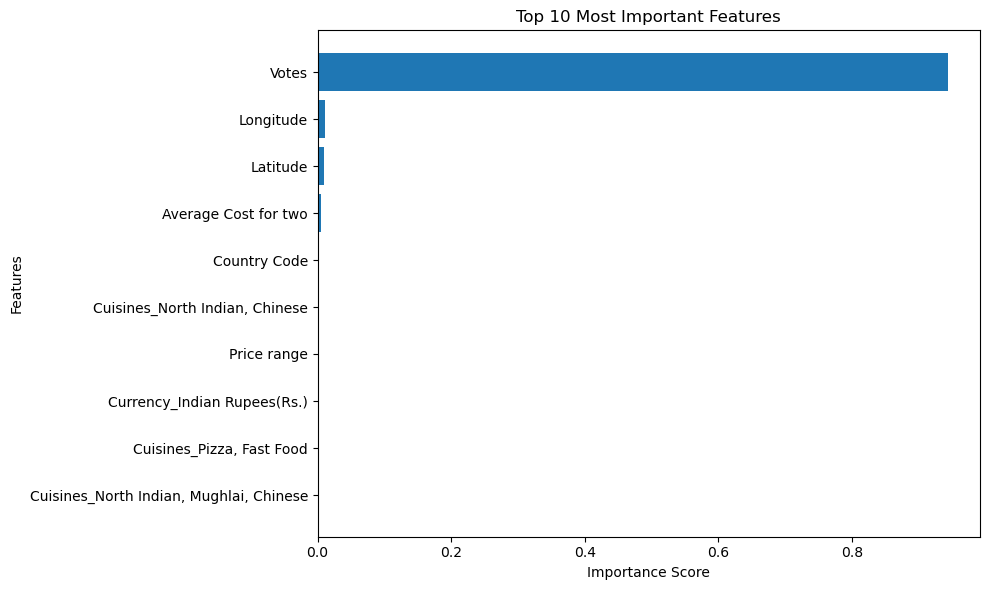

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(all_features[indices], importances[indices])

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# Conclusion

## Summary

This project successfully developed a machine learning model to predict restaurant ratings using restaurant-related features.

### Model Performance

| Model | R² Score |
|--------|----------|
| Random Forest Regressor | **0.9610** |
| Decision Tree Regressor | 0.9320 |
| Linear Regression | 0.4728 |

The **Random Forest Regressor** achieved the highest prediction accuracy among all the evaluated models.

### Key Findings

- Missing values were handled successfully.
- Categorical variables were encoded using One-Hot Encoding.
- Multiple regression models were compared.
- Random Forest provided the best prediction performance.
- Feature importance analysis identified **Votes** as the most influential feature.

### Future Improvements

- Perform hyperparameter tuning using GridSearchCV.
- Apply cross-validation for better model reliability.
- Deploy the trained model using Streamlit.
- Experiment with advanced models such as XGBoost and LightGBM.